# Analyse Exploratoire des Données (Python)

In [ ]:
import pandas as pd
import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import scipy.stats
import scipy.optimize

In [ ]:
!pip install 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: You must give at least one requirement to install (see "pip help install")


In [ ]:
df=pd.read_csv("data-69d3709338fdb705334215.csv")
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,...,6,1,0,0,0,0,0,1,0,Spain
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,...,7,5,0,0,0,0,1,1,0,Canada
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,...,5,2,0,0,0,0,0,0,0,USA
3,1386,1967,Graduation,Together,32474.0,1,1,5/11/2014,0,10,...,2,7,0,0,0,0,0,0,0,Australia
4,5371,1989,Graduation,Single,21474.0,1,0,4/8/2014,0,6,...,2,7,1,0,0,0,0,1,0,Spain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,66476.0,0,1,3/7/2013,99,372,...,11,4,0,0,0,0,0,0,0,USA
2236,5263,1977,2n Cycle,Married,31056.0,1,0,1/22/2013,99,5,...,3,8,0,0,0,0,0,0,0,Spain
2237,22,1976,Graduation,Divorced,46310.0,1,0,12/3/2012,99,185,...,5,8,0,0,0,0,0,0,0,Spain
2238,528,1978,Graduation,Married,65819.0,0,0,11/29/2012,99,267,...,10,3,0,0,0,0,0,0,0,India


# 📊 Description des variables

- **ID** : Identifiant unique du client  
- **Year_Birth** : Année de naissance du client  
- **Education** : Niveau d’éducation du client  
- **Marital_Status** : Statut matrimonial du client  
- **Income** : Revenu annuel du client  : le montant total d'argent gagné par le client en une année
- **Kidhome** : Nombre d’enfants à la maison  
- **Teenhome** : Nombre d’adolescents à la maison  
- **Dt_Customer** : Date d’inscription du client  
- **Recency** : Nombre de jours depuis le dernier achat  
- **MntWines** : Dépenses en vins 🍷
- **MntFruits** : Dépenses en fruits 🍎
- **MntMeatProducts** : Dépenses en produits carnés. viande 🍖 
- **MntFishProducts** : Dépenses en produits de la mer. poisson 🐟  
- **MntSweetProducts** : Dépenses en produits sucrés. 🍬 
- **MntBakedProds** : Dépenses en produits de boulangerie 🍞  
- **NumDealsPurchases** : Nombre d’achats avec réduction التخفيض  
- **NumWebPurchases** : Nombre d’achats en ligne  
- **NumCatalogPurchases** : Nombre d’achats via catalogue  
- **NumStorePurchases** : Nombre d’achats en magasin  
- **NumWebVisitsMonth** : Nombre de visites mensuelles du site web  
- **AcceptedCmp1** : Acceptation de la campagne marketing 1  
- **AcceptedCmp2** : Acceptation de la campagne marketing 2  
- **AcceptedCmp3** : Acceptation de la campagne marketing 3  
- **AcceptedCmp4** : Acceptation de la campagne marketing 4  
- **AcceptedCmp5** : Acceptation de la campagne marketing 5  
- **Response** : Réponse à la dernière campagne marketing  
- **Complain** : Indique si le client a fait une plainte شكوى 
- **Country** : Pays du client  

In [ ]:
#df.dtypes

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4    Income              2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntBakedProds        2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [ ]:
# affichage des colonnes 
df.columns.to_list()

['ID',
 'Year_Birth',
 'Education',
 'Marital_Status',
 ' Income ',
 'Kidhome',
 'Teenhome',
 'Dt_Customer',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntBakedProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Response',
 'Complain',
 'Country']

In [ ]:
# valeurs manquantes
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
 Income                24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntBakedProds           0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Response                0
Complain                0
Country                 0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

**Les types de variables**  : 
- Variables continues: Income, MntWines, MntFruits, MntMeatProducts, MntFishProducts, MntSweetProducts, MntBakedProds
- Variables discrètes catégorielles (nominales): Marital_Status, Country, Complain, Response, AcceptedCmp1 → AcceptedCmp5
- Variables discrètes catégorielles ordinales: Education  
- Variables discrètes numériques: Kidhome,Teenhome,NumDealsPurchases,NumWebPurchase,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Recency,Year_Birth.

Analyse descriptive :

- Le revenu moyen (Income) est supérieur à la médiane, ce qui indique une distribution asymétrique à droite (présence de clients à hauts revenus).

- Les variables de dépenses (MntWines, MntMeatProducts, etc.) présentent une forte dispersion, confirmée par un écart-type élevé, ce qui montre une grande variabilité dans le comportement d’achat des clients.

- Certaines valeurs maximales sont très élevées, suggérant la présence de clients à forte contribution (clients premium) ou d’éventuelles anomalies.

- La variable Recency montre une distribution relativement équilibrée, indiquant une diversité dans la récence des achats.

In [ ]:
statistiques_descriptives=df[['MntWines','MntFruits','MntMeatProducts',
            'MntFishProducts','MntSweetProducts','MntBakedProds','Recency']].describe()
statistiques_descriptives

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntBakedProds,Recency
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,49.109375
std,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,28.962453
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,24.000000
50%,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,49.000000
75%,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,74.000000
max,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,99.000000


Text(0.5, 1.0, 'Comparaison des dépenses en vin selon le pays')

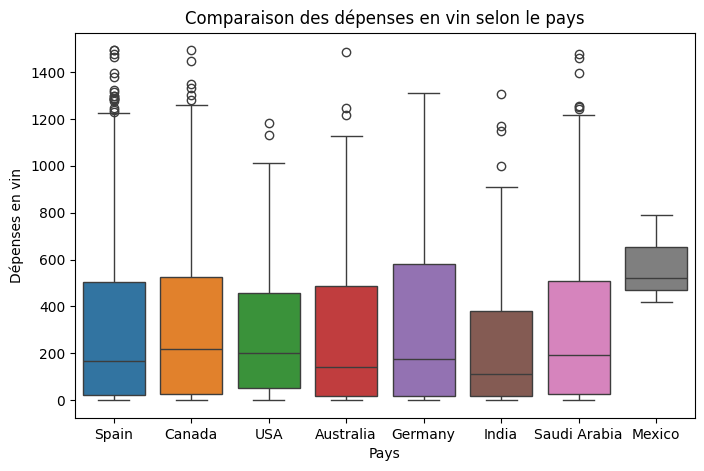

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Country",y="MntWines",hue='Country')
plt.xlabel("Pays")
plt.ylabel("Dépenses en vin")
plt.title("Comparaison des dépenses en vin selon le pays")

In [ ]:
# tableau de contingence : discrets : discrets
pd.crosstab(df["Kidhome"],df["Marital_Status"])

Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Kidhome,,,,,,,,
0,2,0,140,491,268,331,59,2
1,0,3,88,352,201,237,18,0
2,0,0,4,21,11,12,0,0


<Axes: xlabel='Education', ylabel='Country'>

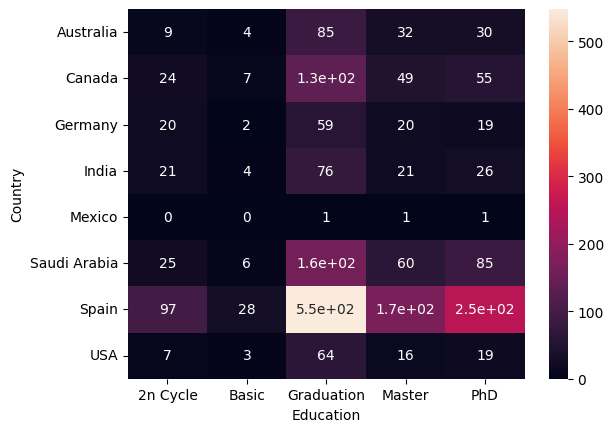

In [ ]:
# tableau de contingence
sns.heatmap(pd.crosstab(df["Country"],df["Education"]),annot=True)

Puisque la moyenne est ici très éloignée de la médiane, cela confirme que les données sont fortement déséquilibrées (asymétriques).

Text(0.5, 1.0, 'Distribution des dépenses en fruits par pays')

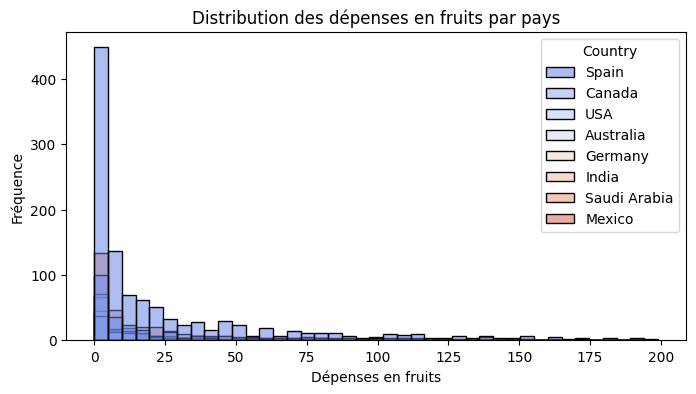

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(data=df,x="MntFruits",hue="Country",palette="coolwarm")
plt.xlabel("Dépenses en fruits")
plt.ylabel("Fréquence")
plt.title("Distribution des dépenses en fruits par pays")

Text(0.5, 1.0, 'Répartition des clients par pays')

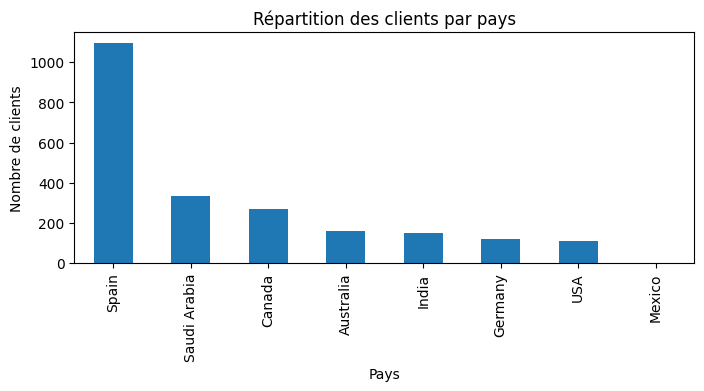

In [ ]:
plt.figure(figsize=(8, 3))
df["Country"].value_counts().plot(kind="bar")
plt.xlabel("Pays")
plt.ylabel("Nombre de clients")
plt.title("Répartition des clients par pays")

<Axes: xlabel='Complain'>

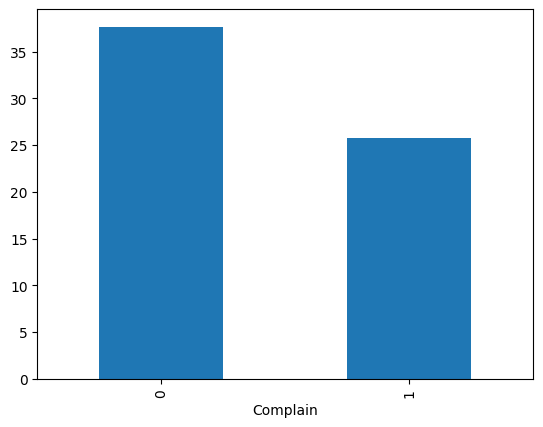

In [ ]:
df.groupby("Complain")["MntFishProducts"].mean().plot(kind="bar")

Text(0, 0.5, '')

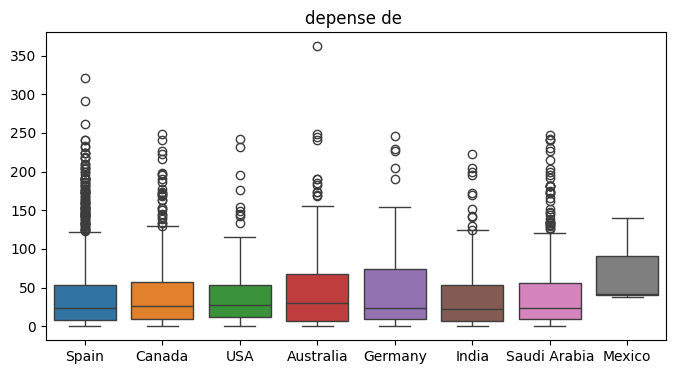

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df,x="Country",y="MntBakedProds",hue="Country")
plt.title("depense de ")
plt.xlabel("")
plt.ylabel("")

Text(0.5, 0, 'Total Sales')

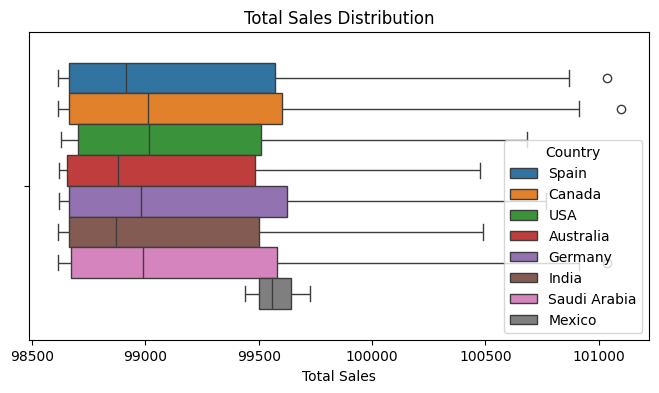

In [ ]:
plt.figure(figsize=(8,4))
total_sales = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntBakedProds'].sum()
sns.boxplot(x=total_sales, hue=df['Country'])
plt.title("Total Sales Distribution")
plt.xlabel("Total Sales")
# count_products = (df['NumDealsPurchases'] + df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases']).sum()
# print(total_sales)
# print(count_products)
#fig, axes = plt.subplots(1, 2, figsize=(12, 6))
#sns.boxplot(x=total_sales, hue=df['Country'], ax=axes[0])
#sns.boxplot(x=total_sales, ax=axes[1])


- **Matrice de corrélation**

<Axes: title={'center': 'Matrice de corrélation des variables numériques'}>

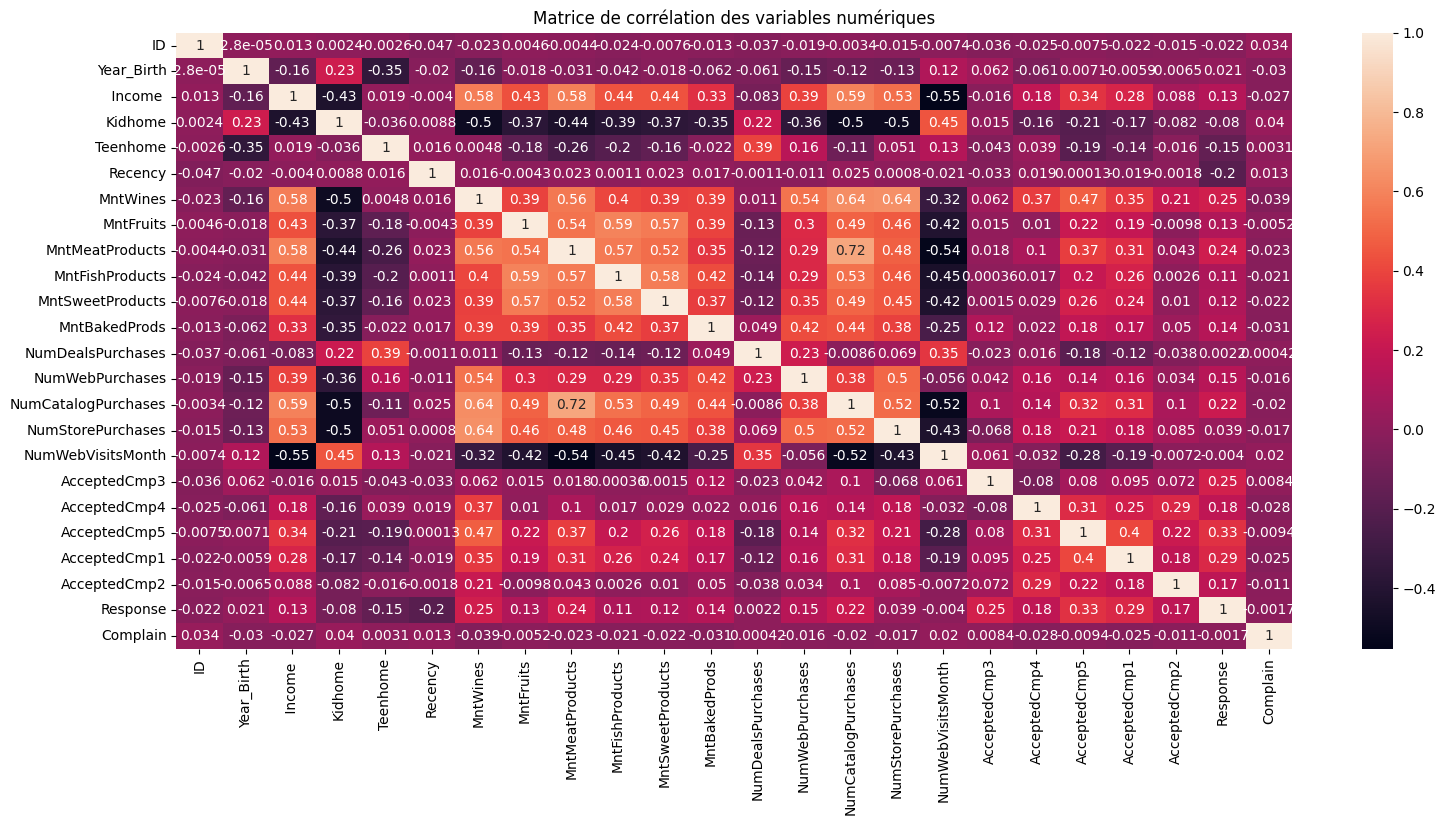

In [ ]:
plt.figure(figsize=(18,8))
plt.title("Matrice de corrélation des variables numériques")
filter_nb = df.select_dtypes(include= 'number')
sns.heatmap (filter_nb.corr() , annot= True)


# Tests Statistiques

In [ ]:
r, p_value = pearsonr(df["MntFishProducts"], df["MntSweetProducts"])
print("Coefficient de corrélation (r) :", r)
print("p-value :", p_value)
alpha = 0.05
if p_value < alpha:
    print('rejected')
else : 
    print("accepted")

Coefficient de corrélation (r) : 0.5798700810242025
p-value : 1.9356513332112192e-201
rejected


In [ ]:
from scipy.stats import pearsonr

# encoder la variable catégorielle
df["Marital_Status_encoded"] = df["Marital_Status"].astype("category").cat.codes

corr, p_value = pearsonr(df["Marital_Status_encoded"], df["Kidhome"])

print("Corrélation :", corr)
print("p-value :", p_value)

Corrélation : -0.02255328580680644
p-value : 0.2859916156607931


In [ ]:
# tableau de contingence
ct = pd.crosstab(df["Education"], df["Marital_Status"])

# test du chi2
chi2, p, dof, expected = chi2_contingency(ct)

print("Chi2 :", chi2)
print("p-value :", p)
print("Degrés de liberté :", dof)

NameError: name 'chi2_contingency' is not defined

<Axes: xlabel='Country', ylabel=' Income '>

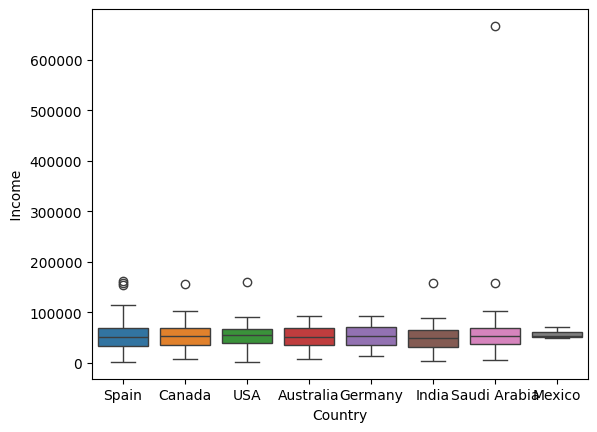

In [ ]:
sns.boxplot(data=df,y=" Income ",x = "Country",hue="Country")

In [ ]:
sns.histplot(data=df,x=" Income ")